In [2]:

import numpy as np

class NeuralNetwork:
    def __init__(self):
        self.weights = np.random.rand(2, 1)
        self.bias = np.random.rand(1)

    def train(self, X, y, epochs):
        for i in range(epochs):
            output = self.predict(X)
            error = y - output
            #backward_prop
            delta = error * output * (1 - output)
            self.weights += np.dot(X.T, delta)
            self.bias += np.sum(delta)

    def predict(self, X):
        return 1 / (1 + np.exp(-(np.dot(X, self.weights) + self.bias))) #forward_Prop

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])

nn = NeuralNetwork()
nn.train(X, y, epochs=1000)

test_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
predictions = nn.predict(test_data)

for x, prediction in zip(test_data, predictions):
    print(f"Input: {x}, Prediction: {prediction}")


Input: [0 0], Prediction: [0.0002455]
Input: [0 1], Prediction: [0.05559549]
Input: [1 0], Prediction: [0.05559549]
Input: [1 1], Prediction: [0.93383012]


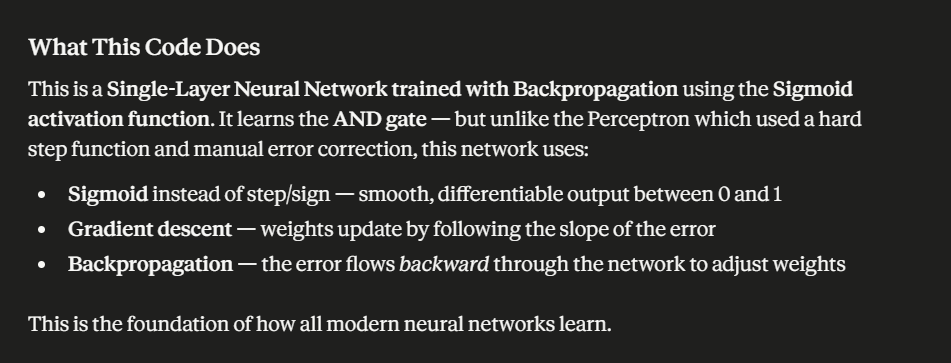

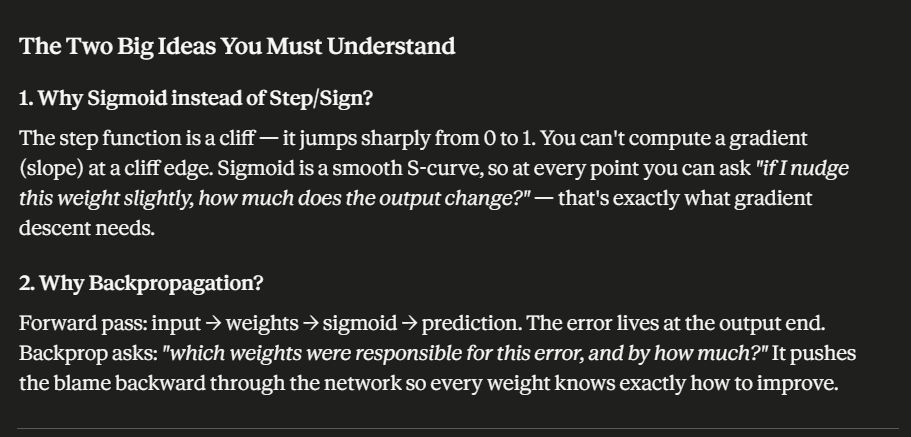

Exam Questions

Q1. What is the difference between the Perceptron learning rule and backpropagation?
Perceptron uses a hard error (label − output, where output is 0 or 1) and updates only on mistakes. Backprop computes a soft gradient using the sigmoid derivative — it always updates, just more or less depending on how wrong it was. Backprop works with any differentiable activation; Perceptron's step function isn't differentiable.

Q2. Why do we need X.T in np.dot(X.T, delta)?
X is shape (4,2) and delta is (4,1). To get a weight update of shape (2,1), we need to transpose X to (2,4) and multiply by delta (4,1). Geometrically, we're summing each input's contribution to the error across all training samples.

Q3. What does output * (1 - output) represent?
It's the derivative of the sigmoid function — how much the output changes for a small change in the weighted sum. It peaks at 0.25 when output=0.5 (maximum uncertainty) and approaches 0 when output is near 0 or 1 (the neuron is confident and changes little).

Q4. Why do we run 1000 epochs and not just 1?
A single pass updates weights based on the current error, but one update rarely gets everything right. Each epoch refines the weights slightly. Over 1000 passes, the network converges — meaning further updates produce negligible improvement.

Q5. What is the vanishing gradient problem and does it apply here?
When output is very close to 0 or 1, output * (1-output) becomes nearly 0 — a tiny gradient. This means weights barely update. In a single-layer network this is manageable, but in deep networks it compounds layer by layer and early layers stop learning entirely. This is why ReLU (from practical 1) was invented.2 / 2